<a href="https://colab.research.google.com/github/Yeabebe/earthquake-detection-ai/blob/main/earthquake_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install numpy pandas scikit-learn tensorflow matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)

import tensorflow as tf

print("Libraries loaded successfully")

Libraries loaded successfully


Upload Dataset

In [2]:
# Upload your CSV file manually in Colab
# Expected filename example:
# earthquake_data.csv

from google.colab import files

uploaded = files.upload()


Saving IEB_export.csv to IEB_export.csv


Load Dataset

In [3]:
df = pd.read_csv("IEB_export.csv")

print("\nDataset Loaded Successfully")
print(df.head())

print("\nDataset Shape:")
print(df.shape)



Dataset Loaded Successfully
   Year  Month  Day      Time     Lat      Lon  Depth  Mag  \
0  2026      5   10  22:01:16  9.3613  40.0258   10.0  4.3   
1  2026      4    1  19:46:02  9.0104  39.9468   10.0  4.3   
2  2026      3   21  19:14:45  8.5088  39.9617   10.0  4.3   
3  2026      2   15  19:39:18  9.0119  39.7337   10.0  4.6   
4  2025     11   17  21:59:24  8.7933  39.9200   10.0  4.5   

                            Region   Timestamp  
0     44 km NNW of Āwash, Ethiopia  1778450476  
1  12 km NNE of Metahāra, Ethiopia  1775072762  
2    43 km S of Metahāra, Ethiopia  1774120485  
3  23 km WNW of Metahāra, Ethiopia  1771184358  
4    11 km S of Metahāra, Ethiopia  1763416764  

Dataset Shape:
(200, 10)


Creat Labels

In [4]:
def classify_magnitude(mag):

    if mag < 4.0:
        return 0   # Mild

    elif mag < 5.0:
        return 1   # Moderate

    elif mag < 6.0:
        return 2   # Strong

    else:
        return 3   # Very Strong


df['label'] = df['Mag'].apply(classify_magnitude)

print("\nLabels Created Successfully")




Labels Created Successfully


Input Features & Labels

In [5]:
X = df[['Lat', 'Lon', 'Depth', 'Mag']]

y = df['label']

print("\nFeatures Prepared Successfully")
print(X.head())


Features Prepared Successfully
      Lat      Lon  Depth  Mag
0  9.3613  40.0258   10.0  4.3
1  9.0104  39.9468   10.0  4.3
2  8.5088  39.9617   10.0  4.3
3  9.0119  39.7337   10.0  4.6
4  8.7933  39.9200   10.0  4.5


Train / Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 160
Testing Samples: 40


Feature Scaling

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nFeature Scaling Completed")


Feature Scaling Completed


Small Neural Network (TinyML-style)

In [31]:
model = tf.keras.Sequential([

    tf.keras.layers.Dense(
        32,
        activation='relu',
        input_shape=(X_train.shape[1],)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation='relu'
    ),

    tf.keras.layers.Dense(
        4,
        activation='softmax'
    )
])

print("\nModel Architecture:")
model.summary()


# COMPILE MODEL
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Compilation Completed")




Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 756 (2.95 KB)

 Trainable params: 756 (2.95 KB)

 Non-trainable params: 0 (0.00 B)


Model Compilation Completed


Train Model

In [32]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0208 - loss: 1.8972 - val_accuracy: 0.0625 - val_loss: 1.9158
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0347 - loss: 1.7555 - val_accuracy: 0.1250 - val_loss: 1.8180
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0833 - loss: 1.6781 - val_accuracy: 0.1875 - val_loss: 1.7300
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1736 - loss: 1.6005 - val_accuracy: 0.1875 - val_loss: 1.6482
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2014 - loss: 1.5024 - val_accuracy: 0.2500 - val_loss: 1.5761
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.2917 - loss: 1.4408 - val_accuracy: 0.3125 - val_loss: 1.5118
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4306 - loss: 1.3604 - val_accuracy: 0.5000 - val_loss: 1.4495
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5278 - loss: 1.3126 - val_accuracy: 0.6250 - val_loss: 1.3914


Evaluate Model

In [33]:
y_pred = np.argmax(
    model.predict(X_test),
    axis=1
)

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.4f}")

print("\nCLASSIFICATION REPORT")
print("---------------------")
print(classification_report(y_test, y_pred))

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Model Accuracy: 0.9500

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.97      0.97      0.97        39
           2       0.00      0.00      0.00         1

    accuracy                           0.95        40
   macro avg       0.32      0.32      0.32        40
weighted avg       0.95      0.95      0.95        40



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

Confusion Matrix

In [34]:
cm = confusion_matrix(y_test, y_pred)

print("CONFUSION MATRIX\n")
print(cm)

CONFUSION MATRIX

[[ 0  0  0]
 [ 1 38  0]
 [ 0  1  0]]


Plot Training Performance

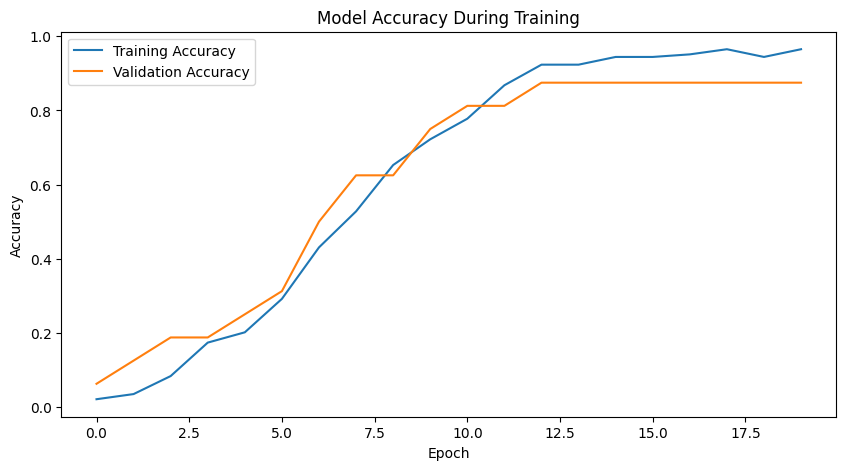

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy During Training')

plt.legend()

plt.show()


Earthquake Prediction Function

In [39]:
def predict_earthquake(lat, lon, depth, mag):

    sample = pd.DataFrame([[
        lat,
        lon,
        depth,
        mag
    ]], columns=['Lat', 'Lon', 'Depth', 'Mag'])

    sample = scaler.transform(sample)

    prediction = model.predict(sample)

    predicted_class = np.argmax(prediction)

    classes = [
        "Mild Earthquake",
        "Moderate Earthquake",
        "Strong Earthquake",
        "Very Strong Earthquake"
    ]

    return classes[predicted_class]

Test Prediction

In [42]:
result = predict_earthquake(
    9.36,     # Latitude
    40.02,    # Longitude
    10.0,     # Depth
    4.3       # Magnitude
)

print("PREDICTION RESULT")
print("-----------------")
print(result)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
PREDICTION RESULT
-----------------
Moderate Earthquake


Save Model

In [43]:
model.save("earthquake_model.h5")
print("\nKeras model saved successfully")


Keras model saved successfully


Convert to TensorFlow Lite (TinyML)

In [44]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("earthquake_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved")

Saved artifact at '/tmp/tmp_3syy41_'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 4), dtype=tf.float32, name='keras_tensor_9')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  137881739677136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137881739679056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137881739678288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137881739679248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137881739684816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137881739677712: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite model saved


Download Models

In [45]:
files.download("earthquake_model.h5")
files.download("earthquake_model.tflite")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>